**Import Libraries**

In [35]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder

# Wordcloud
from wordcloud import WordCloud

# Save model
import pickle

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

**Load Dataset**

In [36]:
df = pd.read_csv("G:\DS_Projects\.venv\AI Echo\data\chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Dell\AppData\Local\Temp\ipykernel_19308\4049920498.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("G:\DS_Projects\.venv\AI Echo\data\chatgpt_style_reviews_dataset.xlsx - Sheet1.csv")


,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No


**Dataset Information**

In [37]:
df.shape

(500, 12)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   date               500 non-null    object
 1   title              500 non-null    object
 2   review             500 non-null    object
 3   rating             500 non-null    int64 
 4   username           500 non-null    object
 5   helpful_votes      500 non-null    int64 
 6   review_length      500 non-null    int64 
 7   platform           500 non-null    object
 8   language           500 non-null    object
 9   location           500 non-null    object
 10  version            500 non-null    object
 11  verified_purchase  500 non-null    object
dtypes: int64(3), object(9)
memory usage: 47.0+ KB


In [39]:
df.columns

Index(['date', 'title', 'review', 'rating', 'username', 'helpful_votes',
       'review_length', 'platform', 'language', 'location', 'version',
       'verified_purchase'],
      dtype='object')

**Missing Values**

In [40]:
df.isnull().sum()

date                 0
title                0
review               0
rating               0
username             0
helpful_votes        0
review_length        0
platform             0
language             0
location             0
version              0
verified_purchase    0
dtype: int64

In [41]:
df = df.dropna(subset=['review'])

**Sentiment Creation**

In [42]:
def get_sentiment(rating):
    
    if rating >= 4:
        return "Positive"
    
    elif rating == 3:
        return "Neutral"
    
    else:
        return "Negative"

df["sentiment"] = df["rating"].apply(get_sentiment)

df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,Negative
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No,Positive
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No,Negative
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,Negative
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No,Negative


In [43]:
df["sentiment"].value_counts()

sentiment
Positive    200
Negative    195
Neutral     105
Name: count, dtype: int64

**Text Preprocessing**

In [44]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [45]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    words = [lemmatizer.lemmatize(w) for w in words]

    return " ".join(words)

In [46]:
df["clean_review"] = df["review"].apply(clean_text)

df.head()

,date,title,review,rating,username,helpful_votes,review_length,platform,language,location,version,verified_purchase,sentiment,clean_review
0,########,Review title 1,"Not satisfied, many bugs and issues.",1,user1,80,6,Amazon,zh,Kenya,2.1.4,No,Negative,satisfied many bug issue
1,########,Review title 2,Amazing quality and user-friendly interface.,5,user2,180,5,Flipkart,zh,France,1.2.3,No,Positive,amazing quality user friendly interface
2,########,Review title 3,"Terrible experience, needs major improvements.",2,user3,154,5,Flipkart,pt,USA,1.2.3,No,Negative,terrible experience need major improvement
3,########,Review title 4,Poor performance and not user-friendly.,1,user4,96,5,Amazon,es,Qatar,2.1.4,Yes,Negative,poor performance user friendly
4,########,Review title 5,"Not satisfied, many bugs and issues.",2,user5,139,6,Website,ar,Kenya,2.1.4,No,Negative,satisfied many bug issue


**EDA**

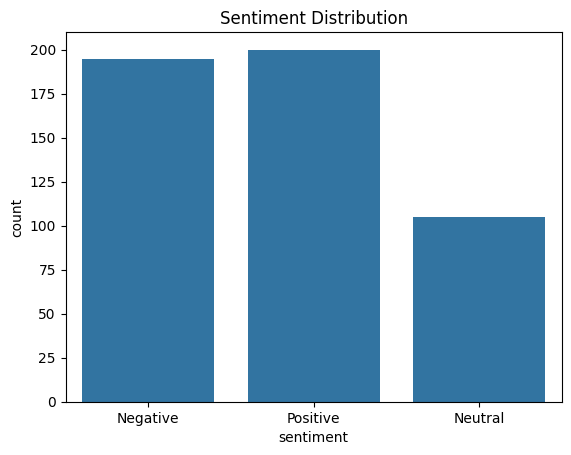

In [47]:
sns.countplot(x="sentiment",data=df)

plt.title("Sentiment Distribution")

plt.show()

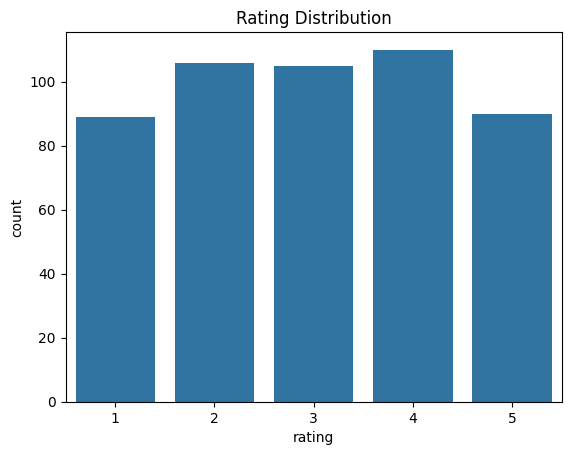

In [48]:
sns.countplot(x="rating",data=df)

plt.title("Rating Distribution")

plt.show()

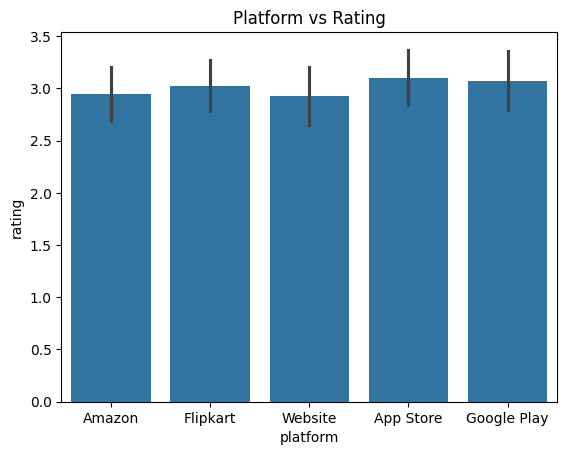

In [49]:
sns.barplot(x="platform",y="rating",data=df)

plt.title("Platform vs Rating")

plt.show()

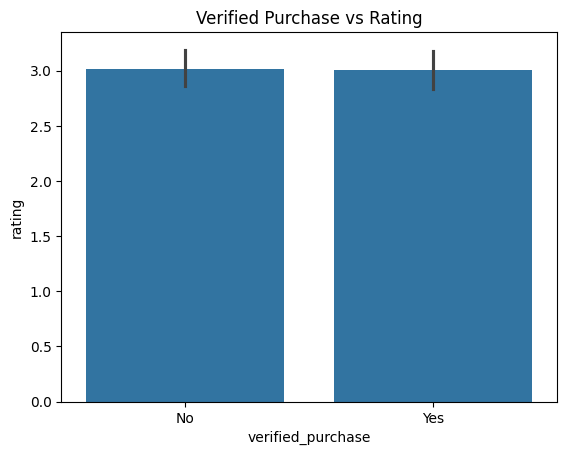

In [50]:
sns.barplot(x="verified_purchase",y="rating",data=df)

plt.title("Verified Purchase vs Rating")

plt.show()

**WordCloud Visualization**

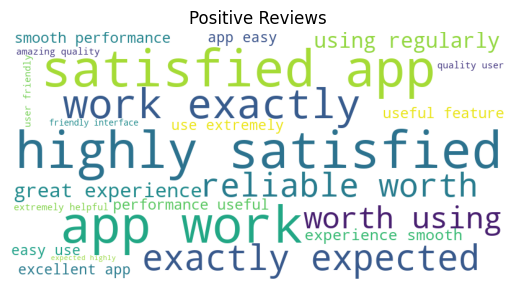

In [51]:
positive_text = " ".join(df[df["sentiment"]=="Positive"]["clean_review"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(positive_text)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Reviews")

plt.show()

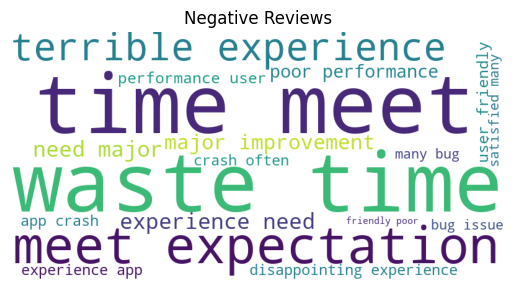

In [52]:
negative_text = " ".join(df[df["sentiment"]=="Negative"]["clean_review"])

wordcloud = WordCloud(width=800,height=400,background_color="white").generate(negative_text)

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Reviews")

plt.show()

**Train Test Split**

In [53]:
X = df["clean_review"]

y = df["sentiment"]

In [54]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

**TF-IDF Vectorization**

In [55]:
tfidf = TfidfVectorizer(max_features=5000)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

**Model Training**

Logistic Regression

In [56]:
lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf,y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

Naive Bayes


In [57]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf,y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

**Model Evaluation**

In [58]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



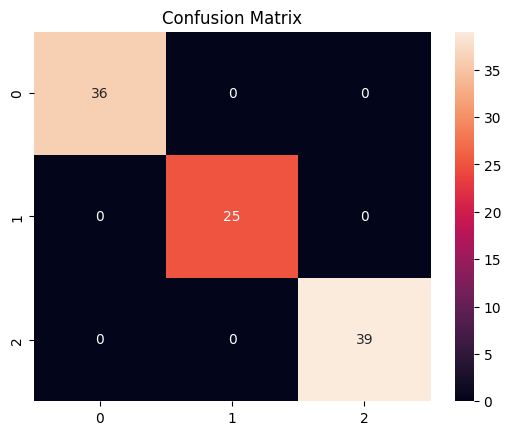

In [59]:
sns.heatmap(confusion_matrix(y_test,y_pred_lr),annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

In [60]:
print(classification_report(y_test,y_pred_nb))

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        36
     Neutral       1.00      1.00      1.00        25
    Positive       1.00      1.00      1.00        39

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



Even though Logistic Regression and Naive Bayes achieved 100% accuracy on this dataset, I implemented a deep learning model (LSTM) to compare traditional machine learning with deep learning approaches. Machine learning models rely on TF-IDF features, whereas LSTM automatically learns contextual patterns in text. Deep learning models are particularly useful for large datasets and capturing sequential information in language.

**Deep Learning Model (LSTM)**

In [62]:
le = LabelEncoder()

y_enc = to_categorical(le.fit_transform(y))

In [63]:
tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df["clean_review"])

seq = tokenizer.texts_to_sequences(df["clean_review"])

X_pad = pad_sequences(seq,maxlen=100)

In [64]:
X_train_dl,X_test_dl,y_train_dl,y_test_dl = train_test_split(
    X_pad,y_enc,test_size=0.2,random_state=42
)

**LSTM Model**

In [65]:
model = Sequential([
    
    Embedding(5000,128,input_length=100),
    
    LSTM(64),
    
    Dense(3,activation="softmax")
])

g:\DS_Projects\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [66]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [67]:
model.fit(
    X_train_dl,
    y_train_dl,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - accuracy: 0.4969 - loss: 1.0548 - val_accuracy: 0.6250 - val_loss: 1.0021
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.6656 - loss: 0.9522 - val_accuracy: 0.8000 - val_loss: 0.9035
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8000 - loss: 0.8293 - val_accuracy: 0.8000 - val_loss: 0.7539
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.8000 - loss: 0.6565 - val_accuracy: 0.8250 - val_loss: 0.5531
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.8938 - loss: 0.4467 - val_accuracy: 0.9375 - val_loss: 0.3314
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step - accuracy: 0.9781 - loss: 0.2553 - val_accuracy: 1.0000 - val_loss: 0.1671
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 1.0000 - loss: 0.1321 - val_accuracy: 1.0000 - val_loss: 0.0874
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 1.0000 - loss: 0.0686 - val_accuracy: 1.0000 - val_loss: 0.04

**Evaluate Deep Learning Model**

In [68]:
loss,accuracy = model.evaluate(X_test_dl,y_test_dl)

print("LSTM Accuracy:",accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 0.0129
LSTM Accuracy: 1.0


**Save Logistic Regression Model (with TF-IDF)**

In [69]:
# Save TF-IDF vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Save Logistic Regression model
with open("sentiment_lr_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

**Save LSTM Model**

In [78]:
model.save(r"G:\DS_Projects\.venv\AI Echo\model\lstm_sentiment_model.keras")

In [74]:
import pickle

# save tokenizer
with open("tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

# save label encoder
with open("label_encoder.pkl","wb") as f:
    pickle.dump(le,f)

I trained both machine learning models (Logistic Regression and Naive Bayes) and a deep learning model (LSTM). Since the project focuses on deep learning for NLP, I saved the LSTM model for deployment. However, I also saved the Logistic Regression model because it is lightweight and useful for quick inference.


**Prediction Function**

In [72]:
def predict_sentiment(text):

    text = clean_text(text)

    vector = tfidf.transform([text])

    prediction = lr_model.predict(vector)

    return prediction[0]

In [73]:
predict_sentiment("This app is amazing and very useful")

'Positive'